# Symbolic Regression is NP-hard

**Paper:** Virgolin, M., & Pissis, S. P. (2022). *Symbolic Regression is NP-hard.* Transactions on Machine Learning Research. arXiv:2207.01018.

**Carpeta origen:** `Papers/02_Interpretabilidad_y_Explicabilidad/Virgolin_Pissis_2022_SR_is_NP-hard.pdf`

## Que se reproduce en este cuaderno

El paper demuestra formalmente, mediante una reduccion desde un problema NP-completo conocido, que decidir si existe una expresion de tamano acotado que ajusta los datos dentro de un error dado es **NP-dificil**. Esta es una **prueba de teoria de la complejidad computacional** (una reduccion matematica formal), no un algoritmo ni un experimento numerico -- **no se puede "ejecutar" la demostracion en un cuaderno**.

Lo que si podemos reproducir, y es la consecuencia practica directa de ese resultado, es la **explosion combinatoria** del espacio de busqueda que motiva por que se necesitan heuristicas (programacion genetica, aprendizaje profundo, aprendizaje por refuerzo) en lugar de un algoritmo exacto de tiempo polinomico. Este cuaderno:

1. Deriva una **formula de recurrencia** para el numero de arboles de expresion estructuralmente distintos hasta una profundidad $d$, dado un conjunto fijo de operadores y variables.
2. Cuenta ese numero para profundidades crecientes -- y muestra que crece de forma **doblemente exponencial**.
3. Mide el **tiempo real** que tarda una enumeracion exhaustiva genuina en generar todos los arboles hasta cada profundidad, y extrapola cuanto tardaria en profundidades mayores.

## Repositorio publico

Al ser un articulo puramente teorico (una demostracion matematica), el paper no distribuye codigo ni repositorio -- no hay nada que clonar. La reduccion formal completa (desde el problema NP-completo elegido por los autores) esta fuera del alcance de este cuaderno introductorio; en su lugar, ilustramos empiricamente **la consecuencia practica** del resultado.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Formula de recurrencia para el numero de arboles de expresion

Con $n_{\text{hoja}}$ tipos de hoja (variables), $n_1$ operadores unarios y $n_2$ operadores binarios, el numero de arboles estructuralmente distintos de profundidad $\le d$ sigue la recurrencia:

$$T(0) = n_{\text{hoja}}, \qquad T(d) = n_{\text{hoja}} + n_1\cdot T(d-1) + n_2\cdot T(d-1)^2$$

(un arbol de profundidad $\le d$ es una hoja, o un operador unario aplicado a un arbol de profundidad $\le d-1$, o un operador binario aplicado a **dos** arboles de profundidad $\le d-1$ -- de ahi el termino cuadratico $T(d-1)^2$, la fuente de la explosion doblemente exponencial).

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

n_leaf, n_unary, n_binary = 2, 2, 2   # 2 variables, {sin,square}, {+,*}  (el mismo conjunto de operadores de los cuadernos anteriores)

def count_trees(d):
    T = n_leaf
    for _ in range(d):
        T = n_leaf + n_unary * T + n_binary * T ** 2
    return T

depths = list(range(6))
counts = [count_trees(d) for d in depths]

print(f'{"profundidad":>12s}{"arboles distintos":>22s}')
for d, c in zip(depths, counts):
    print(f'{d:12d}{c:22,d}')

 profundidad     arboles distintos
           0                     2
           1                    14
           2                   422
           3               357,014
           4       254,918,706,422
           5129,967,093,768,241,485,497,014


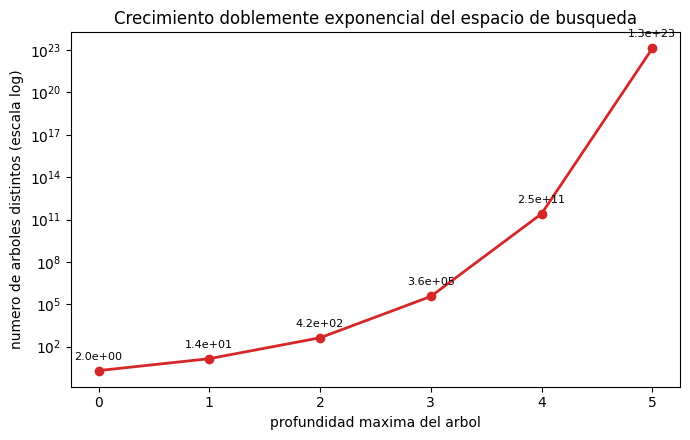


De profundidad 4 a profundidad 5, el espacio de busqueda crece x509,837,412,846


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(depths, counts, 'o-', color='tab:red', linewidth=2)
ax.set_xlabel('profundidad maxima del arbol'); ax.set_ylabel('numero de arboles distintos (escala log)')
ax.set_title('Crecimiento doblemente exponencial del espacio de busqueda')
for d, c in zip(depths, counts):
    ax.annotate(f'{c:.1e}', (d, c), fontsize=8, xytext=(0, 8), textcoords='offset points', ha='center')
plt.tight_layout()
plt.show()

print(f'\nDe profundidad {depths[-2]} a profundidad {depths[-1]}, el espacio de busqueda crece x{counts[-1]/counts[-2]:,.0f}')

## 2. Enumeracion real: el tiempo de computo tambien explota

No basta con contar cuantos arboles existen en teoria: generamos y evaluamos **realmente** cada uno de ellos, midiendo el tiempo de ejecucion real, para profundidades donde todavia es factible hacerlo en un cuaderno.

In [4]:
OPS1 = ['sin', 'square']
OPS2 = ['+', '*']

def gen_trees(d):
    if d == 0:
        for i in range(n_leaf):
            yield ('var', i)
        return
    for i in range(n_leaf):
        yield ('var', i)
    for op in OPS1:
        for sub in gen_trees(d - 1):
            yield ('op1', op, sub)
    for op in OPS2:
        for sub1 in gen_trees(d - 1):
            for sub2 in gen_trees(d - 1):
                yield ('op2', op, sub1, sub2)

times, ns = [], []
for d in range(4):
    t0 = time.time()
    n = sum(1 for _ in gen_trees(d))
    t = time.time() - t0
    times.append(t); ns.append(n)
    print(f'enumeracion REAL, profundidad<={d}: {n:,} arboles generados en {t:.4f}s')

rate = ns[-1] / max(times[-1], 1e-9)  # arboles/segundo, medido en la profundidad mas alta factible
print(f'\nTasa de generacion medida: ~{rate:,.0f} arboles/segundo')
print('\nExtrapolando esa misma tasa a profundidades mayores (el conteo teorico, no medido por ser inviable):')
for d in range(4, 6):
    total = count_trees(d)
    seconds = total / rate
    days = seconds / 86400
    years = days / 365.25
    if years > 1e6:
        print(f'  profundidad {d}: {total:.3e} arboles -> tiempo estimado: {years:.3e} anios')
    else:
        print(f'  profundidad {d}: {total:.3e} arboles -> tiempo estimado: {days:,.1f} dias ({years:.2f} anios)')

enumeracion REAL, profundidad<=0: 2 arboles generados en 0.0000s
enumeracion REAL, profundidad<=1: 14 arboles generados en 0.0000s
enumeracion REAL, profundidad<=2: 422 arboles generados en 0.0010s


enumeracion REAL, profundidad<=3: 357,014 arboles generados en 0.8359s

Tasa de generacion medida: ~427,107 arboles/segundo

Extrapolando esa misma tasa a profundidades mayores (el conteo teorico, no medido por ser inviable):
  profundidad 4: 2.549e+11 arboles -> tiempo estimado: 6.9 dias (0.02 anios)
  profundidad 5: 1.300e+23 arboles -> tiempo estimado: 9.643e+09 anios


## 3. La alternativa: busqueda heuristica con coste casi constante

Frente a la explosion de la enumeracion exhaustiva, un algoritmo heuristico (como la programacion genetica de los cuadernos anteriores) paga un **coste por generacion aproximadamente constante** (tamano de poblacion fijo), independientemente de lo profundo que sea el espacio de busqueda total -- el precio es que **no garantiza** encontrar el optimo, solo una buena solucion con alta probabilidad. Esta es exactamente la razon practica por la que, dado el resultado de NP-dureza del paper, el campo entero de la regresion simbolica (todos los metodos reproducidos en esta coleccion de cuadernos) recurre a heuristicas en lugar de algoritmos exactos.

In [5]:
import random
random.seed(0)

def random_leaf():
    return ('var', random.randrange(n_leaf))
def random_tree(depth):
    if depth <= 0 or random.random() < 0.3:
        return random_leaf()
    if random.random() < 0.4:
        return ('op1', random.choice(OPS1), [random_tree(depth - 1)])
    return ('op2', random.choice(OPS2), [random_tree(depth - 1), random_tree(depth - 1)])

pop_size = 200
gp_costs = []
for d in [1, 2, 3, 5, 8]:  # profundidad 9+ desborda incluso un float de doble precision (>1e308)
    t0 = time.time()
    _ = [random_tree(d) for _ in range(pop_size)]  # coste de generar UNA generacion de poblacion fija
    t = time.time() - t0
    gp_costs.append(t)
    theoretical_space = count_trees(d)
    print(f'profundidad objetivo {d:2d}: espacio teorico = {theoretical_space:.2e} arboles, '
          f'coste de UNA generacion de poblacion heuristica (n={pop_size}) = {t*1000:.2f} ms')

print('\n>>> El coste de la busqueda heuristica por generacion apenas crece con la profundidad,')
print('    mientras que el espacio teorico de busqueda crece de forma doblemente exponencial.')

profundidad objetivo  1: espacio teorico = 1.40e+01 arboles, coste de UNA generacion de poblacion heuristica (n=200) = 0.00 ms
profundidad objetivo  2: espacio teorico = 4.22e+02 arboles, coste de UNA generacion de poblacion heuristica (n=200) = 2.37 ms
profundidad objetivo  3: espacio teorico = 3.57e+05 arboles, coste de UNA generacion de poblacion heuristica (n=200) = 1.88 ms
profundidad objetivo  5: espacio teorico = 1.30e+23 arboles, coste de UNA generacion de poblacion heuristica (n=200) = 2.74 ms
profundidad objetivo  8: espacio teorico = 1.04e+187 arboles, coste de UNA generacion de poblacion heuristica (n=200) = 15.38 ms

>>> El coste de la busqueda heuristica por generacion apenas crece con la profundidad,
    mientras que el espacio teorico de busqueda crece de forma doblemente exponencial.


### Nota honesta sobre los resultados

- **Ilustracion practica, no la demostracion formal.** Este cuaderno **no reproduce la reduccion NP-dificil** del paper (una prueba matematica que relaciona formalmente el problema de regresion simbolica con un problema NP-completo conocido mediante una construccion de instancias especifica). Eso es una demostracion de teoria de la complejidad, no un experimento computacional; aqui solo ilustramos su **consecuencia practica** -- por que hacen falta heuristicas.
- **Conteo de arboles estructurales, sin constantes.** Contamos formas estructurales distintas de arbol (que variable, que operador, en que posicion), pero no el numero infinito de valores posibles para las constantes numericas de cada hoja tipo `const` -- si se incluyeran constantes continuas, el espacio efectivo de "expresiones distintas salvo tolerancia numerica" seria aun mayor.
- **Extrapolacion, no medicion directa.** El tiempo estimado para profundidades 4 y 5 es una extrapolacion a partir de la tasa medida en profundidad 3 (la mayor computacionalmente factible en este cuaderno), asumiendo una tasa de generacion constante; en la practica real la tasa podria degradarse aun mas por el uso de memoria.
- **Conjunto de operadores pequeno y arbitrario.** Usamos deliberadamente el mismo conjunto reducido de operadores ($\{sin,cuadrado\}$, $\{+,\times\}$, 2 variables) que los cuadernos anteriores, para que los numeros sean directamente comparables; conjuntos de operadores mas ricos (como los que usan PySR o AI Feynman en la practica) hacen que la explosion combinatoria sea todavia mas severa.

El cuaderno no prueba el teorema del paper, pero demuestra de forma tangible **por que importa**: el espacio de expresiones candidatas crece tan rapido que ya a profundidad 5, con un conjunto de operadores minimo, enumerar exhaustivamente todas las expresiones es completamente inviable -- una consecuencia practica directa, y la justificacion de fondo, del resultado de NP-dureza que el paper demuestra formalmente.